In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X


array([[-10.19089994,   6.35598312],
       [ -3.4218227 ,  -9.12407378],
       [-10.31459673,   5.90365257],
       ...,
       [  0.54695455,   2.32018153],
       [ -0.12136938,   1.01808377],
       [ -8.98145143,   6.8440234 ]], shape=(1000, 2))

In [4]:
y

array([1, 2, 1, 1, 1, 1, 0, 0, 2, 1, 2, 0, 1, 1, 0, 0, 0, 1, 2, 1, 1, 2,
       1, 0, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 2, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 0, 1, 1, 1, 0, 2, 2, 2, 2, 2, 2, 1,
       2, 0, 0, 0, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 1, 0, 2, 2, 1, 1, 0, 2,
       2, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 1, 0,
       1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 0, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0,
       0, 2, 1, 0, 0, 0, 1, 1, 2, 0, 1, 1, 0, 1, 2, 0, 0, 0, 0, 2, 2, 1,
       2, 1, 2, 1, 0, 1, 2, 0, 1, 2, 0, 1, 0, 1, 1, 2, 2, 0, 1, 0, 2, 2,
       0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 2, 0, 0, 2, 2, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 2,
       0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 1, 1,
       0, 1, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 2, 0, 1, 2, 0, 0, 1, 0, 2, 1,
       2, 2, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 2, 2, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 2, 0, 1, 2, 1, 1, 1, 1, 0, 1, 0, 2, 0, 0,

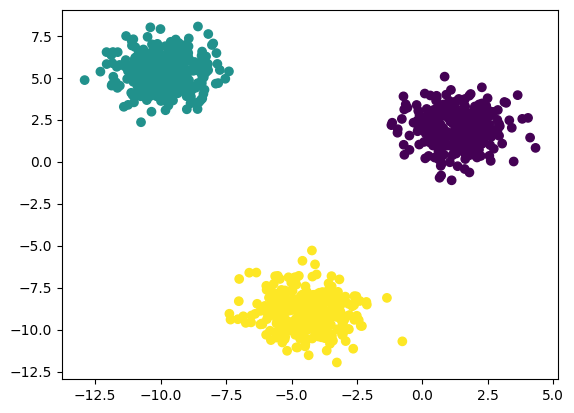

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans


C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

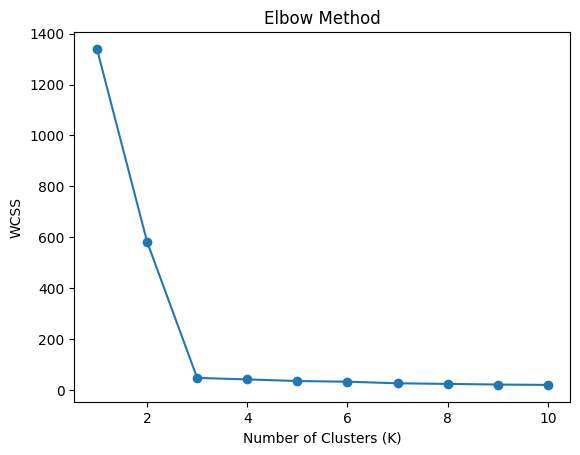

In [15]:
import os
os.environ["OMP_NUM_THREADS"] = "3"

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# Elbow Method
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
    import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [12]:
wcss

[1339.9999999999998,
 718.8514882528289,
 47.08967297541816,
 40.78066482834351,
 34.86299047735914,
 31.720903520119062,
 30.487334883648153,
 22.69812924139805,
 20.00593409785003,
 18.685914546928338]

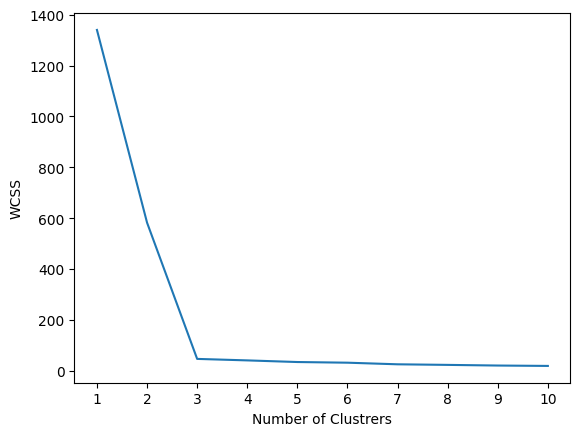

In [16]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [18]:
kmeans.fit_predict(X_train_scaled)

C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([0, 0, 2, 0, 1, 2, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 2, 1, 1, 1, 2, 0,
       0, 2, 1, 2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 1, 2, 0, 1, 0, 2, 0, 2,
       2, 1, 2, 0, 0, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 2, 1,
       1, 2, 0, 2, 0, 0, 1, 0, 1, 0, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 0, 2,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 2, 1, 2, 0, 0, 0,
       1, 0, 2, 2, 1, 0, 0, 2, 1, 2, 1, 2, 1, 0, 2, 0, 1, 1, 2, 1, 0, 0,
       2, 2, 0, 2, 1, 1, 1, 2, 2, 0, 1, 1, 0, 2, 2, 1, 1, 1, 2, 0, 2, 2,
       2, 2, 0, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 2, 1, 2, 0, 0, 2, 0, 0, 1, 2, 0, 2, 2, 2, 0, 0, 2,
       1, 1, 1, 2, 2, 2, 0, 2, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 2,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2, 0, 1, 1, 1, 2, 0, 0, 2, 1,
       0, 1, 1, 0, 1, 2, 1, 1, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 2, 1, 0, 0,
       1, 0, 0, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 0, 2, 0, 2, 1, 2,
       0, 2, 1, 1, 1, 1, 0, 2, 2, 2, 2, 1, 1, 0, 0,

In [19]:
y_pred=kmeans.predict(X_test_scaled)

In [20]:
y_pred

array([2, 2, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 0, 1, 0, 0, 2, 1, 0, 2, 0, 0,
       2, 2, 1, 1, 2, 1, 2, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 2, 1, 2, 0,
       2, 0, 1, 2, 1, 2, 0, 0, 2, 0, 2, 2, 1, 0, 1, 2, 1, 2, 1, 1, 0, 2,
       0, 2, 0, 0, 0, 0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2, 0,
       1, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0,
       0, 2, 2, 1, 2, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 2, 0, 1, 2, 2, 2, 2,
       0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 0, 2, 2, 1, 2, 0, 1,
       0, 1, 0, 2, 0, 2, 1, 1, 0, 2, 1, 2, 0, 1, 0, 2, 0, 1, 1, 1, 2, 0,
       0, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 0, 0, 1, 1, 2, 1, 0, 2, 1, 0,
       0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 0, 1, 0,
       0, 1, 1, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       0, 2, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 1,
       1, 0, 0, 2, 2, 2, 1, 0, 1, 2, 1, 1, 1, 0, 2, 2, 0, 1, 0, 0, 1, 0,
       2, 2, 0, 1, 2, 1, 0, 1, 1, 1, 0, 0, 2, 1, 1,

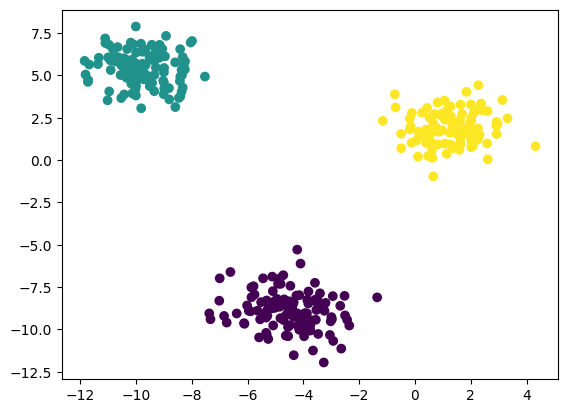

In [21]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [22]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [23]:
## kneelocator
!pip install kneed

In [26]:
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
print("Optimal K value:", kl.elbow)

Optimal K value: 3


C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


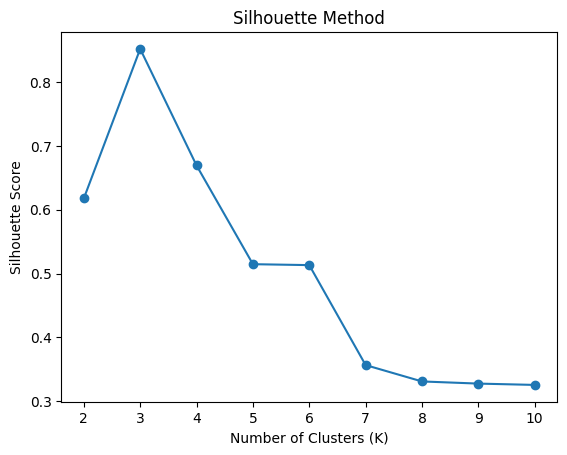

In [29]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
y_pred = kmeans.fit_predict(X_train_scaled)
import matplotlib.pyplot as plt
plt.plot(range(2,11), silhouette_coefficients, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [28]:
silhouette_coefficients

[0.61768223730469,
 0.8517970134084047,
 0.6692879799830767,
 0.5146919116319153,
 0.5132383489278233,
 0.356673058272202,
 0.33106359549655845,
 0.327701928257926,
 0.325625715795585]

In [30]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\KIIT\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

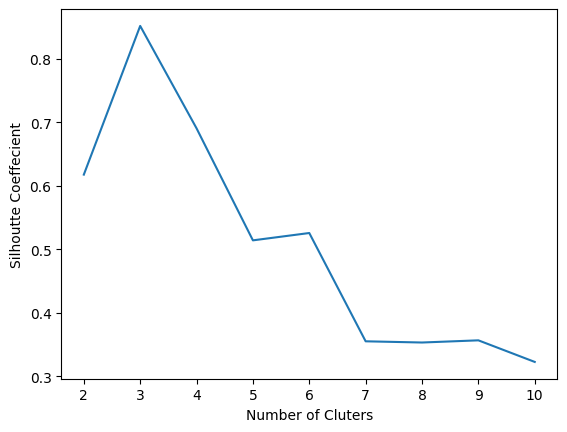

In [31]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()